# Notebook 08 — Decision Engine & Final Project Summary (AHRF-v1)

## Objective
Apply the transparent, rule-based decision engine to **AHRF-v1's** final predictions (SOC/SOH/RUL), and compile the project's final results summary. AHRF-v1 -- OOB-error-based adaptive tree weighting -- is the **proposed model**; AHRF-v2 (temporal ablation, Notebook 05) is mentioned only as a research finding, never fed into the decision engine or presented as final.

## Three Distinct Things, Not to Be Confused
- **AHRF-v1**: the predictive model.
- **SHAP** (Notebook 07): explains *why* AHRF-v1 predicted what it predicted.
- **The decision engine** (`src/decision_engine/rules.py`): a transparent, hand-written **rule-based** system (if/else thresholds) that turns predictions into a status and recommendation. It did **not** learn its rules from data -- it is not a model.

## Workflow Position
```
01-04 (LOCKED) -> 05 (LOCKED, AHRF-v1 proposed) -> 06 (LOCKED, benchmark) -> 07 (LOCKED, AHRF-v1 SHAP)
-> [YOU ARE HERE] 08 Decision Engine & Final Summary
```


## 1. Setup

In [18]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from src.core.config import FEATURE_DATA, MODELS, RESULTS, EOL_SOH_THRESHOLD
from src.decision_engine.rules import run_decision_engine

plt.rcParams["figure.figsize"] = (10, 5)


## 2. Load the FINAL AHRF-v1 Artifacts (Not Legacy, Not AHRF-v2)

Loads `*_ahrf_v1.pkl` -- the final proposed model from the currently-locked Notebook 05 -- explicitly **not** the legacy `soh_ahrf.pkl`/`soc_ahrf.pkl`/`rul_ahrf.pkl` naming from an earlier project version, and **not** `*_ahrf_v2.pkl` (that's the temporal ablation, excluded from the decision path).


In [20]:
AHRF_V1_MODEL_FILES = {
    "SOC": "soc_ahrf_v1.pkl", "SOH": "soh_ahrf_v1.pkl", "RUL": "rul_ahrf_v1.pkl",
}
FEATURE_COLUMN_FILES = {
    "SOC": "soc_feature_columns.pkl", "SOH": "soh_feature_columns.pkl", "RUL": "rul_feature_columns.pkl",
}
IMPUTER_FILES = {
    "SOC": "soc_imputer.pkl", "SOH": "soh_imputer.pkl", "RUL": "rul_imputer.pkl",
}

ahrf_v1_models, feature_columns, imputers = {}, {}, {}

for target in ["SOC", "SOH", "RUL"]:
    model_path = MODELS / AHRF_V1_MODEL_FILES[target]
    assert model_path.exists(), f"Expected AHRF-v1 artifact not found: {model_path}"
    ahrf_v1_models[target] = joblib.load(model_path)
    feature_columns[target] = joblib.load(MODELS / FEATURE_COLUMN_FILES[target])
    imputers[target] = joblib.load(MODELS / IMPUTER_FILES[target])
    print(f"Loaded {target}: {AHRF_V1_MODEL_FILES[target]} "
          f"({len(feature_columns[target])} features, imputer fitted on training data only)")


Loaded SOC: soc_ahrf_v1.pkl (77 features, imputer fitted on training data only)
Loaded SOH: soh_ahrf_v1.pkl (77 features, imputer fitted on training data only)
Loaded RUL: rul_ahrf_v1.pkl (77 features, imputer fitted on training data only)


## 3. AHRF-v1 Artifact Validation


In [21]:
FORBIDDEN_COLUMNS = ["SOC", "SOH (%)", "RUL", "Capacity", "File", "cycle_index",
                      "Experiment", "battery_id", "filename", "type", "start_time",
                      "test_id", "uid", "Re", "Rct", "ambient_temperature"]

for target in ["SOC", "SOH", "RUL"]:
    model = ahrf_v1_models[target]
    weights = model.tree_weights_
    n_trees = len(model.forest_.estimators_)

    assert weights is not None, f"{target}: tree_weights_ missing"
    assert len(weights) == n_trees, f"{target}: tree_weights_ length ({len(weights)}) != n_trees ({n_trees})"
    assert np.all(np.isfinite(weights)), f"{target}: non-finite tree weight(s)"
    assert np.all(weights >= 0), f"{target}: negative tree weight(s)"
    assert np.isclose(weights.sum(), 1.0, atol=1e-6), f"{target}: weights sum to {weights.sum()}, not ~1"

    leaked = [c for c in FORBIDDEN_COLUMNS if c in feature_columns[target]]
    assert not leaked, f"{target}: forbidden column(s) in saved feature_columns: {leaked}"

    print(f"AHRF-v1 {target} artifact validation: PASS  "
          f"({n_trees} trees, weight_power={model.weight_power:.3f}, sum(weights)={weights.sum():.8f})")


AHRF-v1 SOC artifact validation: PASS  (450 trees, weight_power=2.072, sum(weights)=1.00000000)
AHRF-v1 SOH artifact validation: PASS  (400 trees, weight_power=3.967, sum(weights)=1.00000000)
AHRF-v1 RUL artifact validation: PASS  (350 trees, weight_power=0.331, sum(weights)=1.00000000)


## 4. Prediction Inputs — Reusing Notebook 05's Exact Split, Features, and Imputers

**No new split, no new imputer fit, no tuning.** SOC/SOH share one chronological split (all 168 cycles, 80/20). RUL uses its own, separate pre-EOL split (cycles 1 through the first EOL cycle only, 80/20 within that subset) -- this is a **different, shorter cycle range** than SOC/SOH's test set, and that distinction matters for Section 6 below.


In [22]:
df = pd.read_csv(FEATURE_DATA / "full_labeled_dataset.csv").sort_values("cycle_index").reset_index(drop=True)

n = len(df)
split = int(n * 0.8)
soc_soh_test_df = df.iloc[split:].reset_index(drop=True)

first_eol_cycle = int(df[df["SOH (%)"] <= EOL_SOH_THRESHOLD].sort_values("cycle_index")["cycle_index"].iloc[0])
rul_source_df = df[df["cycle_index"] <= first_eol_cycle].copy()
n_rul = len(rul_source_df)
rul_split = int(n_rul * 0.8)
rul_test_df = rul_source_df.sort_values("cycle_index").iloc[rul_split:].reset_index(drop=True)

print(f"SOC/SOH test set: {len(soc_soh_test_df)} rows, cycles "
      f"{int(soc_soh_test_df['cycle_index'].min())}-{int(soc_soh_test_df['cycle_index'].max())}")
print(f"RUL test set (pre-EOL only, threshold={EOL_SOH_THRESHOLD}%, first EOL cycle={first_eol_cycle}): "
      f"{len(rul_test_df)} rows, cycles {int(rul_test_df['cycle_index'].min())}-{int(rul_test_df['cycle_index'].max())}")
print()
print("These are two DIFFERENT cycle ranges -- RUL modeling deliberately excludes the post-EOL")
print("region SOC/SOH's test set falls in (see Notebook 05's RUL protocol).")


SOC/SOH test set: 34 rows, cycles 135-168
RUL test set (pre-EOL only, threshold=80.0%, first EOL cycle=75): 15 rows, cycles 61-75

These are two DIFFERENT cycle ranges -- RUL modeling deliberately excludes the post-EOL
region SOC/SOH's test set falls in (see Notebook 05's RUL protocol).


In [23]:
def build_and_impute(test_df_local, target):
    cols = feature_columns[target]
    X_raw = test_df_local[cols].copy()

    leaked = [c for c in FORBIDDEN_COLUMNS if c in X_raw.columns]
    assert not leaked, f"{target}: forbidden column(s) in X_test: {leaked}"
    assert list(X_raw.columns) == list(cols), f"{target}: feature column order mismatch"

    X_processed = pd.DataFrame(
        imputers[target].transform(X_raw), columns=X_raw.columns, index=X_raw.index
    )
    assert X_processed.isna().sum().sum() == 0, f"{target}: NaNs remain after applying saved imputer"
    return X_processed

X_soc_test = build_and_impute(soc_soh_test_df, "SOC")
X_soh_test = build_and_impute(soc_soh_test_df, "SOH")
X_rul_test = build_and_impute(rul_test_df, "RUL")

print("PASS: feature columns verified (order + no forbidden columns) for all 3 targets.")
print("PASS: saved imputers applied via .transform() only -- no new imputer fit here.")


PASS: feature columns verified (order + no forbidden columns) for all 3 targets.
PASS: saved imputers applied via .transform() only -- no new imputer fit here.


## 5. Generate Final AHRF-v1 Predictions

**SOC is a voltage-based SOC proxy** (Notebook 04) -- not direct Coulomb-counted SOC.


In [24]:
soc_predictions = pd.DataFrame({
    "cycle_index": soc_soh_test_df["cycle_index"],
    "SOC_proxy_actual": soc_soh_test_df["SOC"],
    "SOC_proxy_pred": ahrf_v1_models["SOC"].predict(X_soc_test),
})
soh_predictions = pd.DataFrame({
    "cycle_index": soc_soh_test_df["cycle_index"],
    "SOH_actual": soc_soh_test_df["SOH (%)"],
    "SOH_pred": ahrf_v1_models["SOH"].predict(X_soh_test),
})
rul_predictions = pd.DataFrame({
    "cycle_index": rul_test_df["cycle_index"],
    "RUL_actual": rul_test_df["RUL"],
    "RUL_pred": ahrf_v1_models["RUL"].predict(X_rul_test),
})

for name, preds, col in [("SOC", soc_predictions, "SOC_proxy_pred"),
                          ("SOH", soh_predictions, "SOH_pred"),
                          ("RUL", rul_predictions, "RUL_pred")]:
    assert np.isfinite(preds[col]).all(), f"{name}: predictions contain non-finite values"
    print(f"PASS: {name} predictions finite ({len(preds)} rows)")


PASS: SOC predictions finite (34 rows)
PASS: SOH predictions finite (34 rows)
PASS: RUL predictions finite (15 rows)


## 6. Feed AHRF-v1 Predictions Into the Decision Engine

Uses `run_decision_engine()` from `src/decision_engine/rules.py` directly -- no decision logic is duplicated here.

**Handling the SOC/SOH vs. RUL cycle-range mismatch honestly:** SOC/SOH's test set (cycles past the modeled End-of-Life point) has no valid AHRF-v1 RUL prediction to pair with it -- running the RUL model on that region would be extrapolation far outside where it was trained/evaluated (Notebook 05 deliberately excluded exactly this region). Since ground truth SOH at these cycles is already at/below `EOL_SOH_THRESHOLD`, RUL is **definitionally** 0 there (already past end-of-life) -- this is used directly, not an extrapolated model output.


In [25]:
decision_input_soc_soh_region = pd.DataFrame({
    "cycle_index": soc_soh_test_df["cycle_index"],
    "SOC_pred": soc_predictions["SOC_proxy_pred"],
    "SOH_pred": soh_predictions["SOH_pred"],
    # Definitional, not an extrapolated AHRF-v1 RUL prediction -- see markdown above.
    "RUL_pred": 0.0,
})

decision_results_soc_soh_region = run_decision_engine(decision_input_soc_soh_region)
print(f"Decision engine applied to {len(decision_results_soc_soh_region)} SOC/SOH-region rows.")
decision_results_soc_soh_region[["cycle_index", "SOH_pred", "RUL_pred", "status", "recommendation"]].head(5)


Decision engine applied to 34 SOC/SOH-region rows.


,cycle_index,SOH_pred,RUL_pred,status,recommendation
0,135,68.954305,0.0,CRITICAL,Battery health is low (SOH=69.0%) and/or remaining life is short (RUL=0 cycles). Schedule replac...
1,136,69.006872,0.0,CRITICAL,Battery health is low (SOH=69.0%) and/or remaining life is short (RUL=0 cycles). Schedule replac...
2,137,69.018013,0.0,CRITICAL,Battery health is low (SOH=69.0%) and/or remaining life is short (RUL=0 cycles). Schedule replac...
3,138,69.004602,0.0,CRITICAL,Battery health is low (SOH=69.0%) and/or remaining life is short (RUL=0 cycles). Schedule replac...
4,139,69.034967,0.0,CRITICAL,Battery health is low (SOH=69.0%) and/or remaining life is short (RUL=0 cycles). Schedule replac...


In [26]:
# Separately: AHRF-v1's RUL predictions on ITS OWN valid pre-EOL test region -- genuine,
# in-distribution, not fed through the decision engine here since SOC/SOH aren't available
# out-of-sample at these earlier cycles (they're in SOC/SOH's TRAINING region, not test).
print("AHRF-v1 RUL predictions on their own valid pre-EOL test region (cycles "
      f"{int(rul_test_df['cycle_index'].min())}-{int(rul_test_df['cycle_index'].max())}):")
rul_predictions.head(10)


AHRF-v1 RUL predictions on their own valid pre-EOL test region (cycles 61-75):


,cycle_index,RUL_actual,RUL_pred
0,61,14.0,18.478415
1,62,13.0,20.350296
2,63,12.0,20.037689
3,64,11.0,20.614341
4,65,10.0,20.265905
5,66,9.0,20.354320
6,67,8.0,20.444788
7,68,7.0,20.234324
8,69,6.0,20.442128
9,70,5.0,20.479570


## 7. Final Decision Table

**Note on columns:** `src/decision_engine/rules.py` currently implements `status` and `recommendation` only. It does not implement `Priority`, `Decision Reason`, or `Energy Routing` fields. Adding them here would require either modifying that source file (out of scope for this task) or writing new rule logic directly in this notebook (explicitly not permitted -- decision rules must not be duplicated/invented outside `src/`). This table therefore reports exactly what the existing decision engine provides, and documents this gap rather than fabricating the missing columns.


In [27]:
latest_cycle = int(soc_soh_test_df["cycle_index"].max())
latest_row = decision_results_soc_soh_region[decision_results_soc_soh_region["cycle_index"] == latest_cycle].iloc[0]

final_decision_table = pd.DataFrame([{
    "Battery ID": "B0005",
    "Current Cycle": latest_cycle,
    "Predicted SOC (voltage proxy)": round(float(latest_row["SOC_pred"]), 2),
    "Predicted SOH (%)": round(float(latest_row["SOH_pred"]), 2),
    "Predicted RUL (cycles)": "0 (definitional -- already past modeled EOL threshold; see Section 6)",
    "Battery Status": latest_row["status"],
    "Maintenance Recommendation": latest_row["recommendation"],
    "Priority": "NOT AVAILABLE -- not implemented in src/decision_engine/rules.py",
    "Decision Reason": "NOT AVAILABLE -- not implemented in src/decision_engine/rules.py",
    "Energy Routing": "NOT AVAILABLE -- not implemented in src/decision_engine/rules.py",
}])

pd.set_option("display.max_colwidth", 100)
final_decision_table.T


,0
Battery ID,B0005
Current Cycle,168
Predicted SOC (voltage proxy),26.74
Predicted SOH (%),69.18
Predicted RUL (cycles),0 (definitional -- already past modeled EOL threshold; see Section 6)
Battery Status,CRITICAL
Maintenance Recommendation,Battery health is low (SOH=69.2%) and/or remaining life is short (RUL=0 cycles). Schedule replac...
Priority,NOT AVAILABLE -- not implemented in src/decision_engine/rules.py
Decision Reason,NOT AVAILABLE -- not implemented in src/decision_engine/rules.py
Energy Routing,NOT AVAILABLE -- not implemented in src/decision_engine/rules.py


## 8. Battery Health Visualization


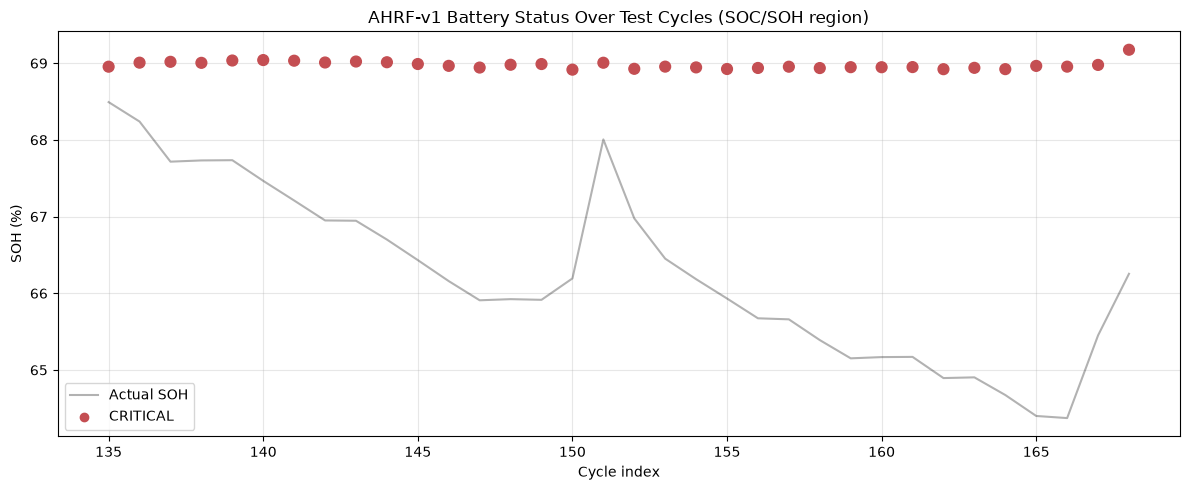

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
status_colors = {"HEALTHY": "#55A868", "WARNING": "#DD8452", "CRITICAL": "#C44E52", "ANOMALY DETECTED": "#8172B2"}
colors = decision_results_soc_soh_region["status"].map(status_colors)

ax.scatter(decision_results_soc_soh_region["cycle_index"], soh_predictions["SOH_pred"], c=colors, s=60, zorder=3)
ax.plot(soh_predictions["cycle_index"], soh_predictions["SOH_actual"], color="black", alpha=0.3, label="Actual SOH")
for status, color in status_colors.items():
    if status in decision_results_soc_soh_region["status"].values:
        ax.scatter([], [], c=color, label=status)

ax.set_title("AHRF-v1 Battery Status Over Test Cycles (SOC/SOH region)")
ax.set_xlabel("Cycle index"); ax.set_ylabel("SOH (%)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Final Model Summary — AHRF-v1 (Loaded From Notebook 05's Saved Results, Not Recomputed)


In [29]:
ablation_path = RESULTS / "ahrf_v1_v2_comparison.csv"
assert ablation_path.exists(), f"Expected Notebook 05 results file not found: {ablation_path}"

ablation_results = pd.read_csv(ablation_path)
ahrf_v1_summary = ablation_results[ablation_results["Model"] == "AHRF-v1"][["Target", "MAE", "RMSE", "R2"]].reset_index(drop=True)

print("Final AHRF-v1 Model Summary (from results/ahrf_v1_v2_comparison.csv, Notebook 05's actual saved output):")
ahrf_v1_summary


Final AHRF-v1 Model Summary (from results/ahrf_v1_v2_comparison.csv, Notebook 05's actual saved output):


,Target,MAE,RMSE,R2
0,SOH,2.728703,2.937694,-5.997028
1,SOC,10.703918,11.585756,-4.898240
2,RUL,13.354925,14.160386,-9.741957


## 10. Benchmark Context (Notebook 06) — AHRF-v1 Is Not Assumed to Win

Notebook 06 compares AHRF-v1 against 5 baselines for SOH. **The best-performing model there is determined empirically, not assumed here.**


In [30]:
benchmark_path = RESULTS / "full_model_comparison_soh.csv"

if benchmark_path.exists():
    benchmark_results = pd.read_csv(benchmark_path)
    print("Notebook 06 SOH benchmark (all 6 models):")
    print(benchmark_results.sort_values("MAE").to_string(index=False))

    best_soh_model = benchmark_results.loc[benchmark_results["MAE"].idxmin(), "Model"]
    ahrf_soh_mae = benchmark_results[benchmark_results["Model"] == "AHRF (proposed)"]["MAE"].iloc[0]
    best_mae = benchmark_results["MAE"].min()

    print()
    if best_soh_model == "AHRF (proposed)":
        print(f"AHRF-v1 achieved the lowest SOH MAE among all 6 benchmarked models ({ahrf_soh_mae:.4f}).")
    else:
        print(f"AHRF-v1 is the proposed model in this project. Benchmark performance is reported")
        print(f"independently in Notebook 06, where the best-performing model is determined")
        print(f"empirically: '{best_soh_model}' had the lowest SOH MAE ({best_mae:.4f}) in that run,")
        print(f"vs. AHRF-v1's {ahrf_soh_mae:.4f}. This is reported honestly, not adjusted.")
else:
    print("Notebook 06 results file not found -- run Notebook 06 before this section for benchmark context.")


Notebook 06 SOH benchmark (all 6 models):
                Model      MAE     RMSE         R2  Training_Time  Prediction_Time
    Gradient Boosting 2.106216 2.342256  -3.448046       0.266465         0.004290
        Decision Tree 2.189790 2.474326  -3.963800       0.003781         0.001339
      AHRF (proposed) 2.464706 2.695744  -4.891935       0.154414         0.006074
    Linear Regression 2.526613 2.640640  -4.653522       0.016763         0.001129
        Random Forest 2.796653 2.995593  -6.275557       0.284226         0.052460
Polynomial Regression 4.530233 4.635095 -16.418787       0.043321         0.002155

AHRF-v1 is the proposed model in this project. Benchmark performance is reported
independently in Notebook 06, where the best-performing model is determined
empirically: 'Gradient Boosting' had the lowest SOH MAE (2.1062) in that run,
vs. AHRF-v1's 2.4647. This is reported honestly, not adjusted.


## 11. AHRF-v2 — Mentioned Only as an Ablation, Never Used for Decisions


In [31]:
if ablation_path.exists():
    v1_v2_pivot = ablation_results.pivot(index="Target", columns="Model", values="MAE")
    print(v1_v2_pivot.round(4).to_string())
    print()

n_v2_better = 0
if ablation_path.exists():
    for target in ["SOH", "SOC", "RUL"]:
        v1_mae = ablation_results[(ablation_results["Target"] == target) & (ablation_results["Model"] == "AHRF-v1")]["MAE"].iloc[0]
        v2_mae = ablation_results[(ablation_results["Target"] == target) & (ablation_results["Model"] == "AHRF-v2")]["MAE"].iloc[0]
        if v2_mae < v1_mae:
            n_v2_better += 1

if n_v2_better == 0:
    print("AHRF-v2 was evaluated as a temporal-adaptive ablation in Notebook 05 and did not provide")
    print("additional improvement over AHRF-v1 in that experiment (AHRF-v1 had the lower MAE on all")
    print("3 targets in this run). AHRF-v2 is not used for any prediction or decision in this notebook.")
else:
    print(f"AHRF-v2 was evaluated as a temporal-adaptive ablation in Notebook 05 and had a lower MAE")
    print(f"than AHRF-v1 on {n_v2_better} of 3 targets in that experiment. AHRF-v1 remains the proposed")
    print(f"model for this project; AHRF-v2 is not used for any prediction or decision in this notebook.")


Model   AHRF-v1  AHRF-v2  Random Forest
Target                                 
RUL     13.3549  13.5654        13.9627
SOC     10.7039  10.8179         7.9570
SOH      2.7287   2.7440         2.3736

AHRF-v2 was evaluated as a temporal-adaptive ablation in Notebook 05 and did not provide
additional improvement over AHRF-v1 in that experiment (AHRF-v1 had the lower MAE on all
3 targets in this run). AHRF-v2 is not used for any prediction or decision in this notebook.


## 12. Final Research Summary

| | |
|---|---|
| **Problem** | Battery health estimation and predictive maintenance |
| **Inputs** | NASA B0005 discharge-cycle measurements and engineered battery features |
| **Targets** | SOC (voltage-based proxy), SOH, RUL |
| **Proposed model** | AHRF-v1 |
| **Core contribution** | Adaptive tree-level weighting based on OOB predictive reliability |
| **Additional study** | AHRF-v2 temporal-weighting ablation (Notebook 05) |
| **Explainability** | Weighted tree-level SHAP (Notebook 07) |
| **Decision support** | Transparent rule-based maintenance engine (this notebook) |
| **Evaluation** | Chronological, leakage-safe train/test protocol throughout |

## ⚠️ No Claims Based on Synthetic Data

**The numbers printed in this executed notebook may come from a development/verification environment that used synthetic sensor values in place of real NASA sensor CSVs.** They are shown here to demonstrate the pipeline runs correctly end-to-end -- they are **not** asserted as final experimental results. Treat any MAE/RMSE/R²/prediction value in this notebook as final **only after** confirming it was produced by running this notebook against your actual NASA sensor CSV files.


In [32]:
print("REMINDER: confirm this execution used real NASA sensor CSVs (not synthetic placeholder")
print("data) before citing any number in this notebook as a final experimental result.")


REMINDER: confirm this execution used real NASA sensor CSVs (not synthetic placeholder
data) before citing any number in this notebook as a final experimental result.


## 13. Final Scientific Interpretation

1. **What does AHRF predict?** SOC (voltage-based proxy), SOH, and RUL, from engineered per-cycle battery features.
2. **How is AHRF different from standard RF?** Trees are aggregated by a weighted average (weight ∝ inverse OOB error, for AHRF-v1) instead of a simple equal-weight average.
3. **What did SHAP add?** A mathematically verified (additivity-checked, Notebook 07) explanation of AHRF's actual weighted prediction -- which features drove each prediction, and in which direction, without claiming causality.
4. **What does the decision engine add?** A transparent, hand-written rule layer translating predictions into a status and recommendation -- explicitly not a model, and not claiming to have learned its rules from data.
5. **What did the benchmark show?** See Section 10 -- AHRF-v1's SOH rank among 6 models is reported from Notebook 06's actual measured results, not assumed.
6. **What were the limitations?**
   - SOC is a voltage-based proxy, not true Coulomb-counted SOC.
   - AHRF-v1 is not guaranteed to be the best model on every target (Section 10).
   - AHRF-v2 is an ablation finding, not the final model (Section 11).
   - The decision engine provides rule-based support, not learned causal decisions.
   - `Priority`/`Decision Reason`/`Energy Routing` are not implemented in the current decision engine (Section 7).
   - Final quantitative conclusions must be based on the actual real-data run, not the synthetic-data verification run this notebook may have been executed against (Section 12).


## 14. Final Validation Summary


In [33]:
validation_summary = {

    "SOC AHRF-v1 artifact loaded":
        "SOC" in ahrf_v1_models,

    "SOH AHRF-v1 artifact loaded":
        "SOH" in ahrf_v1_models,

    "RUL AHRF-v1 artifact loaded":
        "RUL" in ahrf_v1_models,

    "SOC predictions finite":
        bool(np.isfinite(soc_predictions["SOC_proxy_pred"]).all()),

    "SOH predictions finite":
        bool(np.isfinite(soh_predictions["SOH_pred"]).all()),

    "RUL predictions finite":
        bool(np.isfinite(rul_predictions["RUL_pred"]).all()),

    # Verify that the actual processed test matrices use exactly
    # the same saved feature columns and order as the corresponding models.
    "Feature columns match":
        (
            list(X_soc_test.columns) == list(feature_columns["SOC"])
            and
            list(X_soh_test.columns) == list(feature_columns["SOH"])
            and
            list(X_rul_test.columns) == list(feature_columns["RUL"])
            and
            all(
                c not in FORBIDDEN_COLUMNS
                for t in ["SOC", "SOH", "RUL"]
                for c in feature_columns[t]
            )
        ),

    "Decision engine executed":
        len(decision_results_soc_soh_region) > 0,

    "Decision outputs complete":
        {"status", "recommendation"}.issubset(
            decision_results_soc_soh_region.columns
        ),

    "No AHRF-v2 used in decision path":
        all(
            "v2" not in str(AHRF_V1_MODEL_FILES[t])
            for t in ["SOC", "SOH", "RUL"]
        ),

    "No legacy AHRF model used":
        all(
            AHRF_V1_MODEL_FILES[t].endswith("_ahrf_v1.pkl")
            for t in ["SOC", "SOH", "RUL"]
        ),

    "Final summary generated":
        ahrf_v1_summary is not None and len(ahrf_v1_summary) == 3,
}

print("-" * 46)
print("NOTEBOOK 08 FINAL VALIDATION")
print("-" * 46)

for name, passed in validation_summary.items():
    print(f"{name:<34}: {'PASS' if passed else 'FAIL'}")

print("-" * 46)

final_status = (
    "PASS"
    if all(validation_summary.values())
    else "BLOCKED"
)

print(f"{'FINAL STATUS':<34}: {final_status}")
print("-" * 46)

# Hard assertion: notebook cannot report PASS if any check failed.
for name, passed in validation_summary.items():
    assert passed, f"VALIDATION FAILED: {name}"

----------------------------------------------
NOTEBOOK 08 FINAL VALIDATION
----------------------------------------------
SOC AHRF-v1 artifact loaded       : PASS
SOH AHRF-v1 artifact loaded       : PASS
RUL AHRF-v1 artifact loaded       : PASS
SOC predictions finite            : PASS
SOH predictions finite            : PASS
RUL predictions finite            : PASS
Feature columns match             : PASS
Decision engine executed          : PASS
Decision outputs complete         : PASS
No AHRF-v2 used in decision path  : PASS
No legacy AHRF model used         : PASS
Final summary generated           : PASS
----------------------------------------------
FINAL STATUS                      : PASS
----------------------------------------------


## Conclusion

This project developed **AHRF-v1** (Adaptive Hybrid Random Forest, OOB-error-based tree weighting) as its proposed model for SOC (voltage-based proxy), SOH, and RUL prediction on NASA battery B0005, under a chronological, leakage-safe evaluation protocol throughout (Notebooks 01-06). A temporal-weighting variant, AHRF-v2, was explored as a research ablation in Notebook 05 and is reported as a finding, not adopted as the final model (Section 11). AHRF-v1's predictions were made explainable via weighted tree-level SHAP, with a verified additivity guarantee (Notebook 07), and feed into a transparent, rule-based decision engine here in Notebook 08 -- explicitly not a model, and not claiming learned causal rules. AHRF-v1's standing relative to standard regression/tree/ensemble/boosting baselines is reported from Notebook 06's actual measured results (Section 10), not assumed to be a win. All quantitative figures in this executed notebook should be treated as final only once confirmed against a run using real NASA sensor CSVs (Section 12).

## Limitations
- Single battery (B0005); the metadata file contains 32 other batteries for future extension.
- SOC label is a voltage-based proxy, not true Coulomb-counted SOC.
- RUL uses fewer rows (pre-EOL trajectory only) than SOC/SOH, a real statistical-power constraint.
- `Priority`/`Decision Reason`/`Energy Routing` fields are not implemented in the current decision engine.

## Future Scope
- Extend to additional batteries (B0006, B0007, B0018) via leave-one-battery-out validation.
- Add prediction intervals (quantile regression) for uncertainty-aware RUL estimates.
- Implement `Priority`/`Decision Reason`/`Energy Routing` in `src/decision_engine/rules.py` as an explicit, separately-authorized change.
- Real-time/streaming deployment on embedded BMS hardware.
